# Movie Recommendation System

- Load dataset and libraries

In [9]:

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from nltk.stem.porter import PorterStemmer
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
warnings.filterwarnings("ignore")

# Initialize Stemmer
ps = PorterStemmer()
import warnings
warnings.filterwarnings("ignore")

movies = pd.read_csv("../datasets/tmdb_5000_movies.csv")

credits = pd.read_csv("../datasets/tmdb_5000_credits.csv")

print("="*60)
print("Datasets Loaded Successfully")
print("="*60)
plt.style.use("ggplot")

Datasets Loaded Successfully


In [10]:
# ==========================================================
# DATA CLEANING
# Movie Recommendation System
# ==========================================================

# ==========================================================
# Display First Five Rows
# ==========================================================

print("\nMovies Dataset")

display(movies.head())

print("\nCredits Dataset")

display(credits.head())

# ==========================================================
# Dataset Shape
# ==========================================================

print("\nMovies Shape :", movies.shape)

print("Credits Shape :", credits.shape)

# ==========================================================
# Column Names
# ==========================================================

print("\nMovies Columns")

print(movies.columns.tolist())

print("\nCredits Columns")

print(credits.columns.tolist())

# ==========================================================
# Dataset Information
# ==========================================================

print("\nMovies Info")

movies.info()

print("\nCredits Info")

credits.info()

# ==========================================================
# Merge Datasets
# ==========================================================

movies = movies.merge(

    credits,

    on="title"

)

print("\nMerged Dataset Shape")

print(movies.shape)

# ==========================================================
# Select Required Columns
# ==========================================================

movies = movies[

    [

        "movie_id",

        "title",

        "overview",

        "genres",

        "keywords",

        "cast",

        "crew"

    ]

]

print("\nSelected Columns")

display(movies.head())

# ==========================================================
# Missing Values
# ==========================================================

print("\nMissing Values")

print(movies.isnull().sum())

# ==========================================================
# Remove Missing Values
# ==========================================================

movies.dropna(inplace=True)

print("\nAfter Removing Missing Values")

print(movies.shape)

# ==========================================================
# Duplicate Values
# ==========================================================

print("\nDuplicate Rows")

print(movies.duplicated().sum())

# ==========================================================
# Remove Duplicate Rows
# ==========================================================

movies.drop_duplicates(inplace=True)

print("\nAfter Removing Duplicates")

print(movies.shape)

# ==========================================================
# Reset Index
# ==========================================================

movies.reset_index(

    drop=True,

    inplace=True

)

# ==========================================================
# Dataset Summary
# ==========================================================

print("\nDataset Summary")

print(movies.describe(include="all"))

# ==========================================================
# Save Clean Dataset
# ==========================================================

movies.to_csv(

    "../datasets/clean_movies.csv",

    index=False

)

print("\nClean Dataset Saved Successfully")

# ==========================================================
# Final Dataset
# ==========================================================

print("\nFinal Dataset")

display(movies.head())

print("\nFinal Shape")

print(movies.shape)

print("\nData Cleaning Completed Successfully")

print("="*60)


Movies Dataset


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



Credits Dataset


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."



Movies Shape : (4803, 20)
Credits Shape : (4803, 4)

Movies Columns
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits Columns
['movie_id', 'title', 'cast', 'crew']

Movies Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview  

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."



Missing Values
movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

After Removing Missing Values
(4806, 7)

Duplicate Rows
0

After Removing Duplicates
(4806, 7)

Dataset Summary
             movie_id     title  \
count     4806.000000      4806   
unique            NaN      4797   
top               NaN  The Host   
freq              NaN         4   
mean     56922.559509       NaN   
std      88309.447559       NaN   
min          5.000000       NaN   
25%       9009.750000       NaN   
50%      14615.500000       NaN   
75%      58476.750000       NaN   
max     447027.000000       NaN   

                                                 overview  \
count                                                4806   
unique                                               4800   
top     A parasitic alien soul is injected into the bo...   
freq                                                    2   
mean                              

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."



Final Shape
(4806, 7)

Data Cleaning Completed Successfully


# Exploratory Data Analysis (EDA)
- This is the most important phase because we'll create the tags column. The recommendation engine uses this column to find similar movies.

Dataset Loaded Successfully
Dataset Shape
Rows : 4806
Columns : 7
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4806 entries, 0 to 4805
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4806 non-null   int64 
 1   title     4806 non-null   object
 2   overview  4806 non-null   object
 3   genres    4806 non-null   object
 4   keywords  4806 non-null   object
 5   cast      4806 non-null   object
 6   crew      4806 non-null   object
dtypes: int64(1), object(6)
memory usage: 263.0+ KB
Statistical Summary
Missing Values
Duplicate Rows


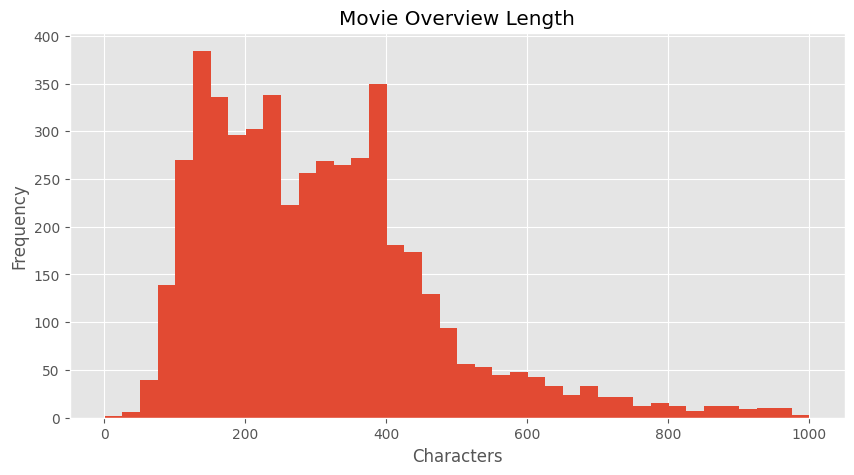

Unique Movies : 4797


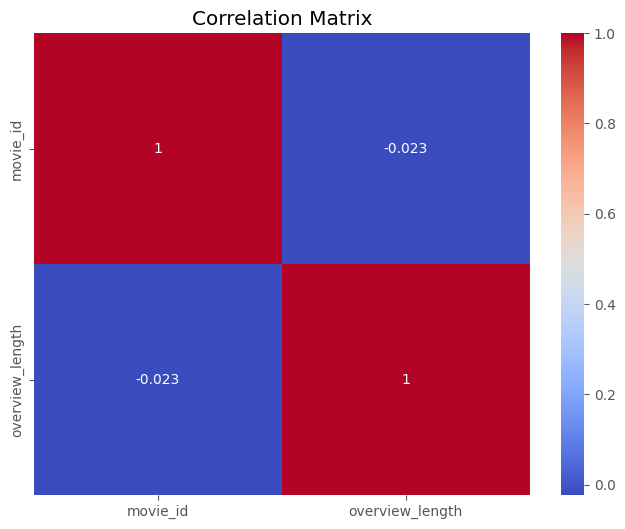

Memory Usage
Memory Used : 38.43 MB


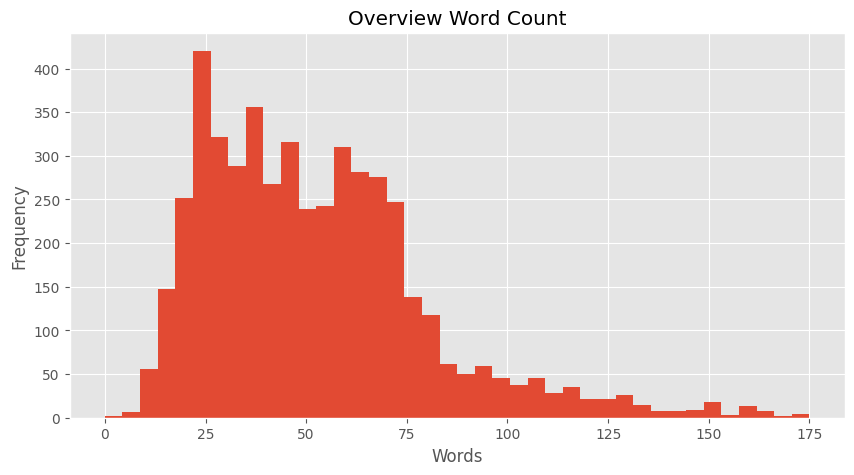

Dataset Saved Successfully


In [11]:
# ==========================================================
# Load  Cleaned Dataset
# ==========================================================

movies = pd.read_csv("../datasets/clean_movies.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

movies.head()

print("="*60)
print("Dataset Shape")
print("="*60)

print("Rows :", movies.shape[0])
print("Columns :", movies.shape[1])

print("="*60)
print("Dataset Information")
print("="*60)

movies.info()
print("="*60)
print("Statistical Summary")
print("="*60)

movies.describe(include="all")

print("="*60)
print("Missing Values")
print("="*60)

movies.isnull().sum()
print("="*60)
print("Duplicate Rows")
print("="*60)

movies.duplicated().sum()

#Random sample
movies.sample(10)
movies.columns.tolist()

movies["overview_length"] = movies["overview"].apply(len)

movies["overview_length"].describe()

plt.figure(figsize=(10,5))

plt.hist(
    movies["overview_length"],
    bins=40
)

plt.title("Movie Overview Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

# top longest overview
movies[
    ["title","overview_length"]
].sort_values(
    by="overview_length",
    ascending=False
).head(10)

#short overviews
movies[
    ["title","overview_length"]
].sort_values(
    by="overview_length"
).head(10)

print("Unique Movies :", movies["title"].nunique())

null_percentage = (
    movies.isnull().sum() /
    len(movies)
) * 100

null_percentage
numeric_df = movies.select_dtypes(include=np.number)

numeric_df.corr()


plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()


print("="*60)
print("Memory Usage")
print("="*60)

movies.memory_usage(deep=True)

print(
    "Memory Used :",
    round(
        movies.memory_usage(deep=True).sum()/1024**2,
        2
    ),
    "MB"
)

movies.dtypes

movies["overview_words"] = movies["overview"].apply(
    lambda x: len(x.split())
)

movies["overview_words"].describe()


plt.figure(figsize=(10,5))

plt.hist(
    movies["overview_words"],
    bins=40
)

plt.title("Overview Word Count")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

movies.head(20)


movies.to_csv(
    "../datasets/clean_movies.csv",
    index=False
)

print("Dataset Saved Successfully")

In [12]:
def convert(text):

    genres = []

    for item in ast.literal_eval(text):

        genres.append(item["name"])
    return genres

movies["genres"] = movies["genres"].apply(convert)

movies.head()
movies["keywords"] = movies["keywords"].apply(convert)

movies.head()

def convert_cast(text):

    cast = []

    counter = 0

    for item in ast.literal_eval(text):

        if counter != 3:

            cast.append(item["name"])

            counter += 1

        else:

            break

    return cast
movies["cast"] = movies["cast"].apply(convert_cast)

movies.head()
def fetch_director(text):

    director = []

    for item in ast.literal_eval(text):

        if item["job"] == "Director":

            director.append(item["name"])

            break

    return director

movies["crew"] = movies["crew"].apply(fetch_director)

movies.head()

movies["overview"] = movies["overview"].apply(lambda x: x.split())

movies.head()

movies["genres"] = movies["genres"].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies["keywords"] = movies["keywords"].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies["cast"] = movies["cast"].apply(
    lambda x: [i.replace(" ", "") for i in x]
)

movies["crew"] = movies["crew"].apply(
    lambda x: [i.replace(" ", "") for i in x]
)


movies["tags"] = (

    movies["overview"]

    + movies["genres"]

    + movies["keywords"]

    + movies["cast"]

    + movies["crew"]

)
new_df = movies[

    [

        "movie_id",

        "title",

        "tags"

    ]

]

new_df.head()
new_df["tags"] = new_df["tags"].apply(
    lambda x: " ".join(x)
)

new_df.head()

new_df["tags"] = new_df["tags"].apply(
    lambda x: x.lower()
)

new_df.head()

new_df.to_csv(

    "../datasets/feature_engineered_movies.csv",

    index=False

)

print("Feature Engineered Dataset Saved Successfully")


Feature Engineered Dataset Saved Successfully


# NLP Text Processing
- In this phase, we will:
- Apply stemming to reduce words to their root forms.
- Normalize text for better similarity computation.
- Prepare the dataset for CountVectorizer in the next phase.
- Save the final processed dataset.

In [13]:
new_df = pd.read_csv("../datasets/feature_engineered_movies.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("\nDataset Shape :", new_df.shape)

display(new_df.head())

# ==========================================================
# Stemming Function
# ==========================================================

def stem(text):

    words = []

    for word in text.split():

        words.append(ps.stem(word))

    return " ".join(words)


# ==========================================================
# Apply Stemming
# ==========================================================

new_df["tags"] = new_df["tags"].apply(stem)

print("=" * 60)
print("Stemming Completed Successfully")
print("=" * 60)

display(new_df.head())

# ==========================================================
# Validate Dataset
# ==========================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

new_df.info()

print("\nMissing Values")
print(new_df.isnull().sum())

print("\nDuplicate Rows")
print(new_df.duplicated().sum())

print("\nRandom Sample")

display(new_df.sample(5))

# ==========================================================
# Sample Processed Tags
# ==========================================================

print("=" * 60)
print("Processed Tags Example")
print("=" * 60)

print(new_df.loc[0, "tags"])

# ==========================================================
# Save NLP Ready Dataset
# ==========================================================

new_df.to_csv(
    "../datasets/nlp_movies.csv",
    index=False
)

print("=" * 60)
print("NLP Dataset Saved Successfully")
print("=" * 60)

print("Saved File : ../datasets/nlp_movies.csv")

Dataset Loaded Successfully

Dataset Shape : (4806, 3)


,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


Stemming Completed Successfully


,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4806 entries, 0 to 4805
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4806 non-null   int64 
 1   title     4806 non-null   object
 2   tags      4806 non-null   object
dtypes: int64(1), object(2)
memory usage: 112.8+ KB

Missing Values
movie_id    0
title       0
tags        0
dtype: int64

Duplicate Rows
0

Random Sample


,movie_id,title,tags
1844,866,Finding Neverland,find neverland is an amus drama about how the ...
900,38050,The Adjustment Bureau,a man glimps the futur fate ha plan for him – ...
1572,9598,Babe,babe is a littl pig who doesn't quit know hi p...
1147,49527,Man on a Ledge,an ex-cop turn con threaten to jump to hi deat...
4529,36825,The R.M.,jare phelp (kirbi heyborne) ha complet two yea...


Processed Tags Example
in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron
NLP Dataset Saved Successfully
Saved File : ../datasets/nlp_movies.csv


# CountVectorizer & Feature Matrix

In [14]:
new_df = pd.read_csv("../datasets/nlp_movies.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("Dataset Shape :", new_df.shape)

display(new_df.head())

# ==========================================================
# Count Vectorizer
# ==========================================================

cv = CountVectorizer(

    max_features=5000,

    stop_words="english"

)

vectors = cv.fit_transform(new_df["tags"]).toarray()

print("=" * 60)
print("Vectorization Completed Successfully")
print("=" * 60)

print("Vector Shape :", vectors.shape)

# ==========================================================
# Vocabulary Information
# ==========================================================

feature_names = cv.get_feature_names_out()

print("=" * 60)
print("Vocabulary Size :", len(feature_names))
print("=" * 60)

print("\nFirst 50 Features\n")

print(feature_names[:50])

print("\nVector Matrix Shape")

print(vectors.shape)

# ==========================================================
# Save CountVectorizer
# ==========================================================

with open("../model/vectorizer.pkl", "wb") as file:

    pickle.dump(cv, file)

print("=" * 60)
print("Vectorizer Saved Successfully")
print("=" * 60)

print("../model/vectorizer.pkl")

# ==========================================================
# Final Verification
# ==========================================================

print("=" * 60)

print("=" * 60)

print("Movies :", new_df.shape[0])

print("Vocabulary :", len(feature_names))

print("Vector Shape :", vectors.shape)

display(new_df.sample(5))

Dataset Loaded Successfully
Dataset Shape : (4806, 3)


,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."


Vectorization Completed Successfully
Vector Shape : (4806, 5000)
Vocabulary Size : 5000

First 50 Features

['000' '007' '10' '100' '11' '12' '13' '14' '15' '16' '17' '17th' '18'
 '18th' '18thcenturi' '19' '1910' '1920' '1930' '1940' '1944' '1950'
 '1950s' '1960' '1960s' '1970' '1970s' '1971' '1974' '1976' '1980' '1985'
 '1990' '1999' '19th' '19thcenturi' '20' '200' '2003' '2009' '20th' '21st'
 '23' '24' '25' '30' '300' '3d' '40' '50']

Vector Matrix Shape
(4806, 5000)
Vectorizer Saved Successfully
../model/vectorizer.pkl
Movies : 4806
Vocabulary : 5000
Vector Shape : (4806, 5000)


,movie_id,title,tags
3272,8293,Howards End,merchant ivory’ adapt of em forster’ classic 1...
3975,191229,Iguana,a grotesqu disfigur harpoon call iguana is sev...
949,71552,American Reunion,the charact we met a littl more than a decad a...
3633,1024,Heavenly Creatures,base on the true stori of juliet hulm and paul...
1139,228967,The Interview,dave skylark and hi produc aaron rapoport run ...


# Cosine Similarity & Recommendation Engine

- Objective: Calculate the similarity between movies using the vectorized tags, create the recommendation function, and save the trained artifacts.

In [15]:
new_df = pd.read_csv("../datasets/nlp_movies.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("Dataset Shape :", new_df.shape)

display(new_df.head())

# ==========================================================
# Create Feature Matrix
# ==========================================================

cv = CountVectorizer(

    max_features=5000,

    stop_words="english"

)

vectors = cv.fit_transform(new_df["tags"]).toarray()

print("Vector Shape :", vectors.shape)

# ==========================================================
# Cosine Similarity
# ==========================================================

similarity = cosine_similarity(vectors)

print("=" * 60)
print("Similarity Matrix Created Successfully")
print("=" * 60)

print("Similarity Shape :", similarity.shape)

# ==========================================================
# Recommendation Function
# ==========================================================

def recommend(movie):

    # Check if movie exists
    if movie not in new_df["title"].values:

        print(f"Movie '{movie}' not found in the dataset.")

        return

    movie_index = new_df[new_df["title"] == movie].index[0]

    distances = similarity[movie_index]

    movies_list = sorted(

        list(enumerate(distances)),

        reverse=True,

        key=lambda x: x[1]

    )[1:6]

    print("=" * 60)
    print(f"Top 5 Recommendations for '{movie}'")
    print("=" * 60)

    for i, movie_data in enumerate(movies_list, start=1):

        print(f"{i}. {new_df.iloc[movie_data[0]].title}")
        # ==========================================================
# Test Recommendation
# ==========================================================

recommend("Avatar")

print()

recommend("Batman Begins")

print()

recommend("The Dark Knight")

# ==========================================================
# Save Models
# ==========================================================

pickle.dump(

    new_df,

    open("../model/movies.pkl", "wb")

)

pickle.dump(

    similarity,

    open("../model/similarity.pkl", "wb")

)

pickle.dump(

    cv,

    open("../model/vectorizer.pkl", "wb")

)

print("=" * 60)
print("Models Saved Successfully")
print("=" * 60)

print("../model/movies.pkl")
print("../model/similarity.pkl")
print("../model/vectorizer.pkl")

Dataset Loaded Successfully
Dataset Shape : (4806, 3)


,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."


Vector Shape : (4806, 5000)
Similarity Matrix Created Successfully
Similarity Shape : (4806, 4806)
Top 5 Recommendations for 'Avatar'
1. Aliens vs Predator: Requiem
2. Aliens
3. Falcon Rising
4. Independence Day
5. Titan A.E.

Top 5 Recommendations for 'Batman Begins'
1. The Dark Knight
2. Batman
3. Batman
4. The Dark Knight Rises
5. 10th & Wolf

Top 5 Recommendations for 'The Dark Knight'
1. The Dark Knight Rises
2. Batman Begins
3. Batman Returns
4. Batman Forever
5. Batman
Models Saved Successfully
../model/movies.pkl
../model/similarity.pkl
../model/vectorizer.pkl
